1. Ładowanie modelu i skalerów...

2. Przetwarzanie danych zdrowych i odprzęgniętych (Ilość plików: 27)...
   Przetwarzanie: ftp75city2_NF.csv (od 0 sekundy)...
   Przetwarzanie: wltp_NF.csv (od 0 sekundy)...
   Przetwarzanie: wltp_NF_2.csv (od 0 sekundy)...
   Przetwarzanie: ftp75city2_f_pic_085.csv (od 0 sekundy)...
   Przetwarzanie: ftp75city2_f_pic_090.csv (od 0 sekundy)...
   Przetwarzanie: ftp75city2_f_pic_095.csv (od 0 sekundy)...
   Przetwarzanie: ftp75city2_f_pic_105.csv (od 0 sekundy)...
   Przetwarzanie: ftp75city2_f_pic_110.csv (od 0 sekundy)...
   Przetwarzanie: ftp75city2_f_pic_115.csv (od 0 sekundy)...
   Przetwarzanie: wltp_f_pic_085.csv (od 0 sekundy)...
   Przetwarzanie: wltp_f_pic_090.csv (od 0 sekundy)...
   Przetwarzanie: wltp_f_pic_095.csv (od 0 sekundy)...
   Przetwarzanie: wltp_f_pic_105.csv (od 0 sekundy)...
   Przetwarzanie: wltp_f_pic_110.csv (od 0 sekundy)...
   Przetwarzanie: wltp_f_pic_115.csv (od 0 sekundy)...
   Przetwarzanie: ftp75city2_f_pim_085.csv (o

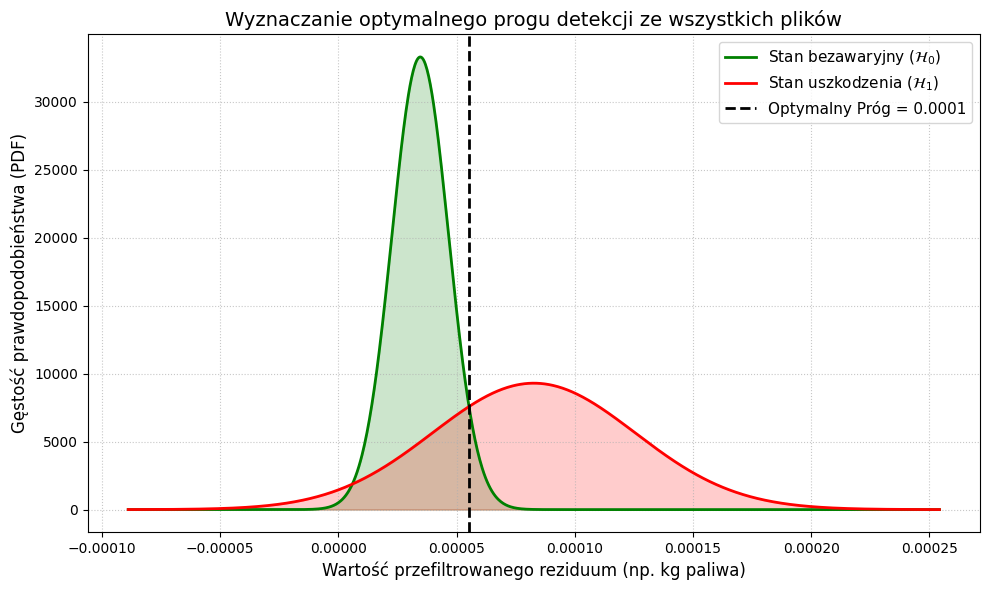

In [3]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import joblib
import matplotlib.pyplot as plt
import scipy.stats as stats
import glob
import os

# ====================================================================
# 1. DEFINICJE SIECI (Wymagane do wczytania wag)
# ====================================================================
class SubNetwork(nn.Module):
    def __init__(self, input_dim, output_dim=1):
        super(SubNetwork, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256), nn.ReLU(),
            nn.Linear(256, 256), nn.ReLU(),
            nn.Linear(256, output_dim)
        )
    def forward(self, x): 
        return self.net(x)

class GreyBoxSystem_WAF(nn.Module):
    def __init__(self, T_sample=0.05, num_states=1):
        super(GreyBoxSystem_WAF, self).__init__()
        self.T, self.num_states, self.num_inputs = T_sample, num_states, 3 
        total_feat = self.num_states + self.num_inputs
        self.g_func = SubNetwork(total_feat, self.num_states) 
        self.h_func = SubNetwork(total_feat, 1)

    def forward(self, u_seq, x_init):
        x_t, preds = x_init, []
        for t in range(u_seq.size(1)):
            inputs = torch.cat((x_t, u_seq[:, t, :]), dim=1)
            preds.append(self.h_func(inputs))
            x_t = x_t + self.T * self.g_func(inputs)
        return torch.stack(preds, dim=1)

# ====================================================================
# 2. FUNKCJE POMOCNICZE: PRZETWARZANIE WIELU PLIKÓW I MATEMATYKA
# ====================================================================
def process_multiple_files(file_list, model, scaler_u, scaler_y, burn_in, alpha, start_time_s=0, freq_Hz=20):
    """Przetwarza listę plików CSV z możliwością pominięcia początkowych sekund."""
    all_residuals = []
    
    # Przeliczenie sekund na indeks próbki
    start_idx = int(start_time_s * freq_Hz)
    
    for file_path in file_list:
        print(f"   Przetwarzanie: {os.path.basename(file_path)} (od {start_time_s} sekundy)...")
        df = pd.read_csv(file_path)
        
        # ZMIANA: Ucinanie pliku, jeśli start_idx > 0
        if start_idx > 0:
            df = df.iloc[start_idx:].copy()
        
        # Inżynieria cech (Droga A) dla MSO WAF
        epsilon = 1e-6
        df['waf_x1'] = np.log(df['engine_speed'] + epsilon) * df['air_mass_flow']
        df['waf_x2'] = df['air_mass_flow']
        df['waf_x3'] = np.log(df['throttle_position'] + epsilon)
        
        u_cols = ['waf_x1', 'waf_x2', 'waf_x3']
        y_cols = ['injected_fuel_mass']
        
        X_tensor = torch.tensor(scaler_u.transform(df[u_cols].values), dtype=torch.float32).unsqueeze(0)
        Y_tensor = torch.tensor(scaler_y.transform(df[y_cols].values), dtype=torch.float32).unsqueeze(0)
        
        x_init = torch.zeros(1, model.num_states)
        y_pred = model(X_tensor, x_init)
        
        y_pred_real = scaler_y.inverse_transform(y_pred[0].cpu().numpy().reshape(-1, 1))
        y_true_real = scaler_y.inverse_transform(Y_tensor[0].cpu().numpy().reshape(-1, 1))
        
        e_raw_abs = np.abs(y_true_real - y_pred_real).flatten()
        e_filtered = np.zeros_like(e_raw_abs)
        e_filtered[0] = e_raw_abs[0]
        
        for i in range(1, len(e_raw_abs)):
            e_filtered[i] = alpha * e_raw_abs[i] + (1 - alpha) * e_filtered[i-1]
            
        # Zapisujemy wygładzone reziduum, ucinając tylko początkowy skok (burn_in)
        all_residuals.extend(e_filtered[burn_in:])
        
    return np.array(all_residuals)

def solve_gaussian_intersection(m1, s1, m2, s2):
    """Znajduje matematyczny punkt przecięcia dwóch rozkładów normalnych."""
    if s1 == s2:
        return (m1 + m2) / 2.0
    
    A = 1/(2*s2**2) - 1/(2*s1**2)
    B = m1/(s1**2) - m2/(s2**2)
    C = m2**2 /(2*s2**2) - m1**2 /(2*s1**2) - np.log(s1/s2)
    
    roots = np.roots([A, B, C])
    
    for root in roots:
        if min(m1, m2) < root < max(m1, m2):
            return root
            
    return np.mean(roots) 

# ====================================================================
# 3. GŁÓWNY SKRYPT
# ====================================================================
if __name__ == "__main__":
    # --- KONFIGURACJA ---
    czestotliwosc_Hz = 20
    burn_in = 100    
    alpha = 0.001 
    DATA_DIR = r"C:\Users\anton\OneDrive\Desktop\data"
    
    # Automatyczne zaciąganie wszystkich plików
    HEALTHY_FILES = glob.glob(os.path.join(DATA_DIR, "*_NF*.csv"))
    PIM_FILES = glob.glob(os.path.join(DATA_DIR, "*_pim_*.csv"))
    PIC_FILES = glob.glob(os.path.join(DATA_DIR, "*_pic_*.csv"))
    WAF_FILES = glob.glob(os.path.join(DATA_DIR, "*_waf_*.csv"))
    IML_FILES = glob.glob(os.path.join(DATA_DIR, "*_iml_*.csv")) 

    # ---------------------------------------------------------
    # NAPRAWA: KOSZYKI FIZYCZNE ZGODNE Z MACIERZĄ FSM
    # ---------------------------------------------------------
    # H0: Sieć WAF nie widzi tych usterek, więc rezyduum będzie płaskie
    FILES_H0 = HEALTHY_FILES + PIC_FILES + PIM_FILES
    
    # H1: Sieć WAF reaguje na te usterki (najlepiej wyliczać próg dla WAF)
    # Wrzucamy tu tylko uszkodzenia przepływomierza
    FILES_H1 = WAF_FILES 
    # ---------------------------------------------------------
    
    print("1. Ładowanie modelu i skalerów...")
    model_waf = GreyBoxSystem_WAF()
    model_waf.load_state_dict(torch.load(r"C:\Users\anton\OneDrive\Desktop\Diagnosis_System\source\waf_article\szara_skrzynka_waf_wagi.pth"))
    model_waf.eval()
    
    scaler_uwaf = joblib.load(r"C:\Users\anton\OneDrive\Desktop\Diagnosis_System\source\waf_article\scaler_u_waf.pkl")
    scaler_ywaf = joblib.load(r"C:\Users\anton\OneDrive\Desktop\Diagnosis_System\source\waf_article\scaler_y_waf.pkl")
    
    print(f"\n2. Przetwarzanie danych zdrowych i odprzęgniętych (Ilość plików: {len(FILES_H0)})...")
    with torch.no_grad():
        # ZDROWE: Od 0 sekundy (całe pliki)
        res_zdrowe = process_multiple_files(FILES_H0, model_waf, scaler_uwaf, scaler_ywaf, burn_in, alpha, start_time_s=0, freq_Hz=czestotliwosc_Hz)
        
    print(f"\n3. Przetwarzanie danych z awarią MAF (Ilość plików: {len(FILES_H1)})...")
    with torch.no_grad():
        # ZEPSUTE: Od 130 sekundy (omijamy zdrowy początek w plikach z usterką)
        res_usterka = process_multiple_files(FILES_H1, model_waf, scaler_uwaf, scaler_ywaf, burn_in, alpha, start_time_s=130, freq_Hz=czestotliwosc_Hz)
        
    # --- STATYSTYKA ---
    mu_0, sigma_0 = np.mean(res_zdrowe), np.std(res_zdrowe)
    mu_1, sigma_1 = np.mean(res_usterka), np.std(res_usterka)
    
    # Obliczenie optymalnego progu
    optimal_threshold = solve_gaussian_intersection(mu_0, sigma_0, mu_1, sigma_1)
    
    # ... (reszta Twojego kodu z rysowaniem wykresów pozostaje bez zmian) ...
    
    print(f"\n{'='*50}")
    print(" WYNIKI OPTYMALIZACJI PROGU NA PEŁNYCH DANYCH")
    print(f"{'='*50}")
    print(f"Dane Zdrowe (H0): mu = {mu_0:.5f}, sigma = {sigma_0:.5f} (na {len(res_zdrowe)} próbkach)")
    print(f"Dane Uszkodz (H1): mu = {mu_1:.5f}, sigma = {sigma_1:.5f} (na {len(res_usterka)} próbkach)")
    print(f"--------------------------------------------------")
    print(f"🚀 OPTYMALNY PRÓG DETEKCJI (Threshold): {optimal_threshold:.5f}")
    print(f"--------------------------------------------------")

    # ====================================================================
    # 4. TWORZENIE NAUKOWEGO WYKRESU
    # ====================================================================
    plt.figure(figsize=(10, 6))
    
    x = np.linspace(min(mu_0 - 4*sigma_0, mu_1 - 4*sigma_1), 
                    max(mu_0 + 4*sigma_0, mu_1 + 4*sigma_1), 1000)
    
    pdf_zdrowe = stats.norm.pdf(x, mu_0, sigma_0)
    pdf_usterka = stats.norm.pdf(x, mu_1, sigma_1)
    
    plt.plot(x, pdf_zdrowe, color='green', linewidth=2, label=r'Stan bezawaryjny ($\mathcal{H}_0$)')
    plt.fill_between(x, pdf_zdrowe, alpha=0.2, color='green')
    
    plt.plot(x, pdf_usterka, color='red', linewidth=2, label=r'Stan uszkodzenia ($\mathcal{H}_1$)')
    plt.fill_between(x, pdf_usterka, alpha=0.2, color='red')
    
    plt.axvline(optimal_threshold, color='black', linestyle='--', linewidth=2, 
                label=f'Optymalny Próg = {optimal_threshold:.4f}')
    
    plt.title('Wyznaczanie optymalnego progu detekcji ze wszystkich plików', fontsize=14)
    plt.xlabel('Wartość przefiltrowanego reziduum (np. kg paliwa)', fontsize=12)
    plt.ylabel('Gęstość prawdopodobieństwa (PDF)', fontsize=12)
    plt.legend(fontsize=11)
    plt.grid(True, linestyle=':', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

1. Ładowanie modelu i skalerów dla MSO 0...

2. Przetwarzanie danych zdrowych i odprzęgniętych (Ilość plików: 15)...
   Przetwarzanie: ftp75city2_NF.csv (od 0 sekundy)...
   Przetwarzanie: wltp_NF.csv (od 0 sekundy)...
   Przetwarzanie: wltp_NF_2.csv (od 0 sekundy)...
   Przetwarzanie: ftp75city2_f_waf_085.csv (od 0 sekundy)...
   Przetwarzanie: ftp75city2_f_waf_090.csv (od 0 sekundy)...
   Przetwarzanie: ftp75city2_f_waf_095.csv (od 0 sekundy)...
   Przetwarzanie: ftp75city2_f_waf_105.csv (od 0 sekundy)...
   Przetwarzanie: ftp75city2_f_waf_110.csv (od 0 sekundy)...
   Przetwarzanie: ftp75city2_f_waf_115.csv (od 0 sekundy)...
   Przetwarzanie: wltp_f_waf_085.csv (od 0 sekundy)...
   Przetwarzanie: wltp_f_waf_090.csv (od 0 sekundy)...
   Przetwarzanie: wltp_f_waf_095.csv (od 0 sekundy)...
   Przetwarzanie: wltp_f_waf_105.csv (od 0 sekundy)...
   Przetwarzanie: wltp_f_waf_110.csv (od 0 sekundy)...
   Przetwarzanie: wltp_f_waf_115.csv (od 0 sekundy)...

3. Przetwarzanie danych z awariami

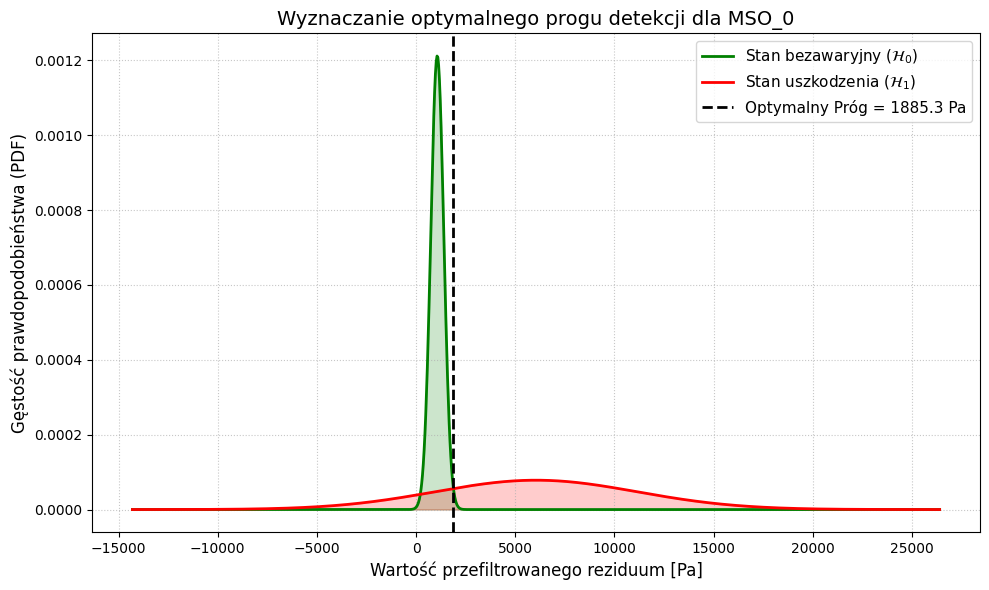

In [4]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import joblib
import matplotlib.pyplot as plt
import scipy.stats as stats
import glob
import os

# ====================================================================
# 1. DEFINICJE SIECI
# ====================================================================
class SubNetwork(nn.Module):
    def __init__(self, input_dim, output_dim=1):
        super(SubNetwork, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256), nn.ReLU(),
            nn.Linear(256, 256), nn.ReLU(),
            nn.Linear(256, output_dim)
        )
    def forward(self, x): 
        return self.net(x)

class GreyBoxSystem_MSO0(nn.Module):
    def __init__(self, T_sample=0.05, num_states=1):
        super(GreyBoxSystem_MSO0, self).__init__()
        # MSO 0 ma 4 wejścia (p_ic, T_ic, przepustnica, obroty)
        self.T, self.num_states, self.num_inputs = T_sample, num_states, 4 
        total_feat = self.num_states + self.num_inputs
        self.g_func = SubNetwork(total_feat, self.num_states) 
        self.h_func = SubNetwork(total_feat, 1)

    def forward(self, u_seq, x_init):
        x_t, preds = x_init, []
        for t in range(u_seq.size(1)):
            inputs = torch.cat((x_t, u_seq[:, t, :]), dim=1)
            preds.append(self.h_func(inputs))
            x_t = x_t + self.T * self.g_func(inputs)
        return torch.stack(preds, dim=1)

# ====================================================================
# 2. FUNKCJE POMOCNICZE
# ====================================================================
def process_multiple_files(file_list, model, scaler_u, scaler_y, burn_in, alpha, start_time_s=0, freq_Hz=20):
    """Przetwarza listę plików CSV z możliwością pominięcia początkowych sekund."""
    all_residuals = []
    start_idx = int(start_time_s * freq_Hz)
    
    # Kolumny dla MSO 0
    u_cols = ['Intercooler_pressure', 'intercooler_temperature', 'throttle_position', 'engine_speed']
    y_cols = ['intake_manifold_pressure']
    
    for file_path in file_list:
        print(f"   Przetwarzanie: {os.path.basename(file_path)} (od {start_time_s} sekundy)...")
        df = pd.read_csv(file_path)
        
        if start_idx > 0:
            df = df.iloc[start_idx:].copy()
        
        X_tensor = torch.tensor(scaler_u.transform(df[u_cols].values), dtype=torch.float32).unsqueeze(0)
        Y_tensor = torch.tensor(scaler_y.transform(df[y_cols].values), dtype=torch.float32).unsqueeze(0)
        
        x_init = torch.zeros(1, model.num_states)
        y_pred = model(X_tensor, x_init)
        
        y_pred_real = scaler_y.inverse_transform(y_pred[0].cpu().numpy().reshape(-1, 1))
        y_true_real = scaler_y.inverse_transform(Y_tensor[0].cpu().numpy().reshape(-1, 1))
        
        e_raw_abs = np.abs(y_true_real - y_pred_real).flatten()
        e_filtered = np.zeros_like(e_raw_abs)
        e_filtered[0] = e_raw_abs[0]
        
        for i in range(1, len(e_raw_abs)):
            e_filtered[i] = alpha * e_raw_abs[i] + (1 - alpha) * e_filtered[i-1]
            
        all_residuals.extend(e_filtered[burn_in:])
        
    return np.array(all_residuals)

def solve_gaussian_intersection(m1, s1, m2, s2):
    """Znajduje matematyczny punkt przecięcia dwóch rozkładów normalnych."""
    if s1 == s2:
        return (m1 + m2) / 2.0
    
    A = 1/(2*s2**2) - 1/(2*s1**2)
    B = m1/(s1**2) - m2/(s2**2)
    C = m2**2 /(2*s2**2) - m1**2 /(2*s1**2) - np.log(s1/s2)
    
    roots = np.roots([A, B, C])
    for root in roots:
        if min(m1, m2) < root < max(m1, m2):
            return root
            
    return np.mean(roots) 

# ====================================================================
# 3. GŁÓWNY SKRYPT
# ====================================================================
if __name__ == "__main__":
    # --- KONFIGURACJA ---
    czestotliwosc_Hz = 20
    burn_in = 100    
    alpha = 0.001 
    DATA_DIR = r"C:\Users\anton\OneDrive\Desktop\data"
    
    # Automatyczne zaciąganie plików
    HEALTHY_FILES = glob.glob(os.path.join(DATA_DIR, "*_NF*.csv"))
    PIM_FILES = glob.glob(os.path.join(DATA_DIR, "*_pim_*.csv"))
    PIC_FILES = glob.glob(os.path.join(DATA_DIR, "*_pic_*.csv"))
    WAF_FILES = glob.glob(os.path.join(DATA_DIR, "*_waf_*.csv"))
    IML_FILES = glob.glob(os.path.join(DATA_DIR, "*_iml_*.csv")) 

    # ---------------------------------------------------------
    # KOSZYKI FIZYCZNE ZGODNE Z MACIERZĄ FSM DLA MSO_0
    # ---------------------------------------------------------
    # H0: Sieć MSO_0 NIE WIDZI uszkodzeń przepływomierza (WAF)
    FILES_H0 = HEALTHY_FILES + WAF_FILES
    
    # H1: Sieć MSO_0 REAGUJE na usterki PIC, PIM oraz wyciek IML.
    # Używamy ich wszystkich do wyznaczenia uśrednionego progu dla każdej z awarii.
    FILES_H1 = PIC_FILES + PIM_FILES + IML_FILES
    # ---------------------------------------------------------
    
    print("1. Ładowanie modelu i skalerów dla MSO 0...")
    model0 = GreyBoxSystem_MSO0()
    # Pamiętaj o dostosowaniu ścieżek, jeśli są inne!
    model0.load_state_dict(torch.load(r"C:\Users\anton\OneDrive\Desktop\Diagnosis_System\source\0\szara_skrzynka_mso0.pth"))
    model0.eval()
    
    scaler_u0 = joblib.load(r"C:\Users\anton\OneDrive\Desktop\Diagnosis_System\source\0\scaler_u_mso0.pkl")
    scaler_y0 = joblib.load(r"C:\Users\anton\OneDrive\Desktop\Diagnosis_System\source\0\scaler_y_mso0.pkl")
    
    print(f"\n2. Przetwarzanie danych zdrowych i odprzęgniętych (Ilość plików: {len(FILES_H0)})...")
    with torch.no_grad():
        res_zdrowe = process_multiple_files(FILES_H0, model0, scaler_u0, scaler_y0, burn_in, alpha, start_time_s=0, freq_Hz=czestotliwosc_Hz)
        
    print(f"\n3. Przetwarzanie danych z awariami (Ilość plików: {len(FILES_H1)})...")
    with torch.no_grad():
        res_usterka = process_multiple_files(FILES_H1, model0, scaler_u0, scaler_y0, burn_in, alpha, start_time_s=130, freq_Hz=czestotliwosc_Hz)
        
    # --- STATYSTYKA ---
    mu_0, sigma_0 = np.mean(res_zdrowe), np.std(res_zdrowe)
    mu_1, sigma_1 = np.mean(res_usterka), np.std(res_usterka)
    
    # Obliczenie optymalnego progu
    optimal_threshold = solve_gaussian_intersection(mu_0, sigma_0, mu_1, sigma_1)
    
    print(f"\n{'='*50}")
    print(" WYNIKI OPTYMALIZACJI PROGU MSO 0 (Stoustrup & Niemann)")
    print(f"{'='*50}")
    print(f"Dane Zdrowe (H0): mu = {mu_0:.2f}, sigma = {sigma_0:.2f} (na {len(res_zdrowe)} próbkach)")
    print(f"Dane Uszkodz (H1): mu = {mu_1:.2f}, sigma = {sigma_1:.2f} (na {len(res_usterka)} próbkach)")
    print(f"--------------------------------------------------")
    print(f"🚀 OPTYMALNY PRÓG DETEKCJI (Threshold): {optimal_threshold:.2f} Pa")
    print(f"--------------------------------------------------")

    # ====================================================================
    # 4. TWORZENIE NAUKOWEGO WYKRESU
    # ====================================================================
    plt.figure(figsize=(10, 6))
    
    x = np.linspace(min(mu_0 - 4*sigma_0, mu_1 - 4*sigma_1), 
                    max(mu_0 + 4*sigma_0, mu_1 + 4*sigma_1), 1000)
    
    pdf_zdrowe = stats.norm.pdf(x, mu_0, sigma_0)
    pdf_usterka = stats.norm.pdf(x, mu_1, sigma_1)
    
    plt.plot(x, pdf_zdrowe, color='green', linewidth=2, label=r'Stan bezawaryjny ($\mathcal{H}_0$)')
    plt.fill_between(x, pdf_zdrowe, alpha=0.2, color='green')
    
    plt.plot(x, pdf_usterka, color='red', linewidth=2, label=r'Stan uszkodzenia ($\mathcal{H}_1$)')
    plt.fill_between(x, pdf_usterka, alpha=0.2, color='red')
    
    plt.axvline(optimal_threshold, color='black', linestyle='--', linewidth=2, 
                label=f'Optymalny Próg = {optimal_threshold:.1f} Pa')
    
    plt.title('Wyznaczanie optymalnego progu detekcji dla MSO_0', fontsize=14)
    plt.xlabel('Wartość przefiltrowanego reziduum [Pa]', fontsize=12)
    plt.ylabel('Gęstość prawdopodobieństwa (PDF)', fontsize=12)
    plt.legend(fontsize=11)
    plt.grid(True, linestyle=':', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

1. Ładowanie modelu i skalerów dla MSO 1...

2. Przetwarzanie danych zdrowych i odprzęgniętych (Ilość plików: 27)...
   Przetwarzanie: ftp75city2_NF.csv (od 0 sekundy)...
   Przetwarzanie: wltp_NF.csv (od 0 sekundy)...
   Przetwarzanie: wltp_NF_2.csv (od 0 sekundy)...
   Przetwarzanie: ftp75city2_f_pic_085.csv (od 0 sekundy)...
   Przetwarzanie: ftp75city2_f_pic_090.csv (od 0 sekundy)...
   Przetwarzanie: ftp75city2_f_pic_095.csv (od 0 sekundy)...
   Przetwarzanie: ftp75city2_f_pic_105.csv (od 0 sekundy)...
   Przetwarzanie: ftp75city2_f_pic_110.csv (od 0 sekundy)...
   Przetwarzanie: ftp75city2_f_pic_115.csv (od 0 sekundy)...
   Przetwarzanie: wltp_f_pic_085.csv (od 0 sekundy)...
   Przetwarzanie: wltp_f_pic_090.csv (od 0 sekundy)...
   Przetwarzanie: wltp_f_pic_095.csv (od 0 sekundy)...
   Przetwarzanie: wltp_f_pic_105.csv (od 0 sekundy)...
   Przetwarzanie: wltp_f_pic_110.csv (od 0 sekundy)...
   Przetwarzanie: wltp_f_pic_115.csv (od 0 sekundy)...
   Przetwarzanie: ftp75city2_f_waf_

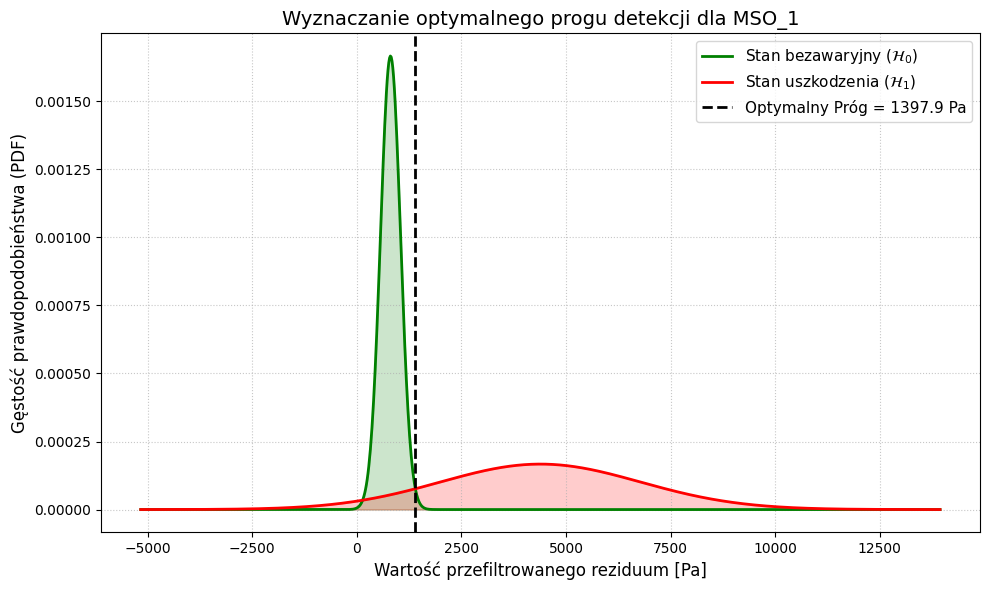

In [5]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import joblib
import matplotlib.pyplot as plt
import scipy.stats as stats
import glob
import os

# ====================================================================
# 1. DEFINICJE SIECI
# ====================================================================
class SubNetwork(nn.Module):
    def __init__(self, input_dim, output_dim=1):
        super(SubNetwork, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256), nn.ReLU(),
            nn.Linear(256, 256), nn.ReLU(),
            nn.Linear(256, output_dim)
        )
    def forward(self, x): 
        return self.net(x)

class GreyBoxSystem_MSO1(nn.Module):
    def __init__(self, T_sample=0.05, num_states=5): # ZMIANA: 5 stanów
        super(GreyBoxSystem_MSO1, self).__init__()
        # ZMIANA: MSO 1 ma 7 wejść i 5 stanów
        self.T, self.num_states, self.num_inputs = T_sample, num_states, 7 
        total_feat = self.num_states + self.num_inputs
        self.g_func = SubNetwork(total_feat, self.num_states) 
        self.h_func = SubNetwork(total_feat, 1)

    def forward(self, u_seq, x_init):
        x_t, preds = x_init, []
        for t in range(u_seq.size(1)):
            inputs = torch.cat((x_t, u_seq[:, t, :]), dim=1)
            preds.append(self.h_func(inputs))
            x_t = x_t + self.T * self.g_func(inputs)
        return torch.stack(preds, dim=1)

# ====================================================================
# 2. FUNKCJE POMOCNICZE
# ====================================================================
def process_multiple_files(file_list, model, scaler_u, scaler_y, burn_in, alpha, start_time_s=0, freq_Hz=20):
    all_residuals = []
    start_idx = int(start_time_s * freq_Hz)
    
    # ZMIANA: Kolumny wejściowe i wyjściowe dla MSO 1
    u_cols = ['ambient_pressure', 'ambient_temperature', 'intercooler_temperature', 
              'throttle_position', 'engine_speed', 'injected_fuel_mass', 'wastegate_position']
    y_cols = ['intake_manifold_pressure']
    
    for file_path in file_list:
        print(f"   Przetwarzanie: {os.path.basename(file_path)} (od {start_time_s} sekundy)...")
        df = pd.read_csv(file_path)
        
        if start_idx > 0:
            df = df.iloc[start_idx:].copy()
        
        X_tensor = torch.tensor(scaler_u.transform(df[u_cols].values), dtype=torch.float32).unsqueeze(0)
        Y_tensor = torch.tensor(scaler_y.transform(df[y_cols].values), dtype=torch.float32).unsqueeze(0)
        
        x_init = torch.zeros(1, model.num_states)
        y_pred = model(X_tensor, x_init)
        
        y_pred_real = scaler_y.inverse_transform(y_pred[0].cpu().numpy().reshape(-1, 1))
        y_true_real = scaler_y.inverse_transform(Y_tensor[0].cpu().numpy().reshape(-1, 1))
        
        e_raw_abs = np.abs(y_true_real - y_pred_real).flatten()
        e_filtered = np.zeros_like(e_raw_abs)
        e_filtered[0] = e_raw_abs[0]
        
        for i in range(1, len(e_raw_abs)):
            e_filtered[i] = alpha * e_raw_abs[i] + (1 - alpha) * e_filtered[i-1]
            
        all_residuals.extend(e_filtered[burn_in:])
        
    return np.array(all_residuals)

def solve_gaussian_intersection(m1, s1, m2, s2):
    if s1 == s2:
        return (m1 + m2) / 2.0
    
    A = 1/(2*s2**2) - 1/(2*s1**2)
    B = m1/(s1**2) - m2/(s2**2)
    C = m2**2 /(2*s2**2) - m1**2 /(2*s1**2) - np.log(s1/s2)
    
    roots = np.roots([A, B, C])
    for root in roots:
        if min(m1, m2) < root < max(m1, m2):
            return root
            
    return np.mean(roots) 

# ====================================================================
# 3. GŁÓWNY SKRYPT
# ====================================================================
if __name__ == "__main__":
    czestotliwosc_Hz = 20
    burn_in = 100    
    alpha = 0.001 
    DATA_DIR = r"C:\Users\anton\OneDrive\Desktop\data"
    
    HEALTHY_FILES = glob.glob(os.path.join(DATA_DIR, "*_NF*.csv"))
    PIM_FILES = glob.glob(os.path.join(DATA_DIR, "*_pim_*.csv"))
    PIC_FILES = glob.glob(os.path.join(DATA_DIR, "*_pic_*.csv"))
    WAF_FILES = glob.glob(os.path.join(DATA_DIR, "*_waf_*.csv"))
    IML_FILES = glob.glob(os.path.join(DATA_DIR, "*_iml_*.csv")) 

    # ---------------------------------------------------------
    # KOSZYKI FIZYCZNE ZGODNE Z MACIERZĄ FSM DLA MSO_1
    # ---------------------------------------------------------
    # H0: MSO 1 NIE REAGUJE na PIC oraz WAF. Wrzucamy je do "zdrowych"
    FILES_H0 = HEALTHY_FILES + PIC_FILES + WAF_FILES
    
    # H1: MSO 1 REAGUJE na PIM oraz IML. 
    FILES_H1 = PIM_FILES + IML_FILES
    # ---------------------------------------------------------
    
    print("1. Ładowanie modelu i skalerów dla MSO 1...")
    model1 = GreyBoxSystem_MSO1()
    model1.load_state_dict(torch.load(r"C:\Users\anton\OneDrive\Desktop\Diagnosis_System\source\1\szara_skrzynka_mso1_wagi.pth"))
    model1.eval()
    
    scaler_u1 = joblib.load(r"C:\Users\anton\OneDrive\Desktop\Diagnosis_System\source\1\scaler_u_mso1.pkl")
    scaler_y1 = joblib.load(r"C:\Users\anton\OneDrive\Desktop\Diagnosis_System\source\1\scaler_y_mso1.pkl")
    
    print(f"\n2. Przetwarzanie danych zdrowych i odprzęgniętych (Ilość plików: {len(FILES_H0)})...")
    with torch.no_grad():
        res_zdrowe = process_multiple_files(FILES_H0, model1, scaler_u1, scaler_y1, burn_in, alpha, start_time_s=0, freq_Hz=czestotliwosc_Hz)
        
    print(f"\n3. Przetwarzanie danych z awariami (Ilość plików: {len(FILES_H1)})...")
    with torch.no_grad():
        res_usterka = process_multiple_files(FILES_H1, model1, scaler_u1, scaler_y1, burn_in, alpha, start_time_s=130, freq_Hz=czestotliwosc_Hz)
        
    # --- STATYSTYKA ---
    mu_0, sigma_0 = np.mean(res_zdrowe), np.std(res_zdrowe)
    mu_1, sigma_1 = np.mean(res_usterka), np.std(res_usterka)
    
    optimal_threshold = solve_gaussian_intersection(mu_0, sigma_0, mu_1, sigma_1)
    
    print(f"\n{'='*50}")
    print(" WYNIKI OPTYMALIZACJI PROGU MSO 1 (Stoustrup & Niemann)")
    print(f"{'='*50}")
    print(f"Dane Zdrowe (H0): mu = {mu_0:.2f}, sigma = {sigma_0:.2f} (na {len(res_zdrowe)} próbkach)")
    print(f"Dane Uszkodz (H1): mu = {mu_1:.2f}, sigma = {sigma_1:.2f} (na {len(res_usterka)} próbkach)")
    print(f"--------------------------------------------------")
    print(f"🚀 OPTYMALNY PRÓG DETEKCJI (Threshold): {optimal_threshold:.2f} Pa")
    print(f"--------------------------------------------------")

    # ====================================================================
    # 4. TWORZENIE NAUKOWEGO WYKRESU
    # ====================================================================
    plt.figure(figsize=(10, 6))
    
    x = np.linspace(min(mu_0 - 4*sigma_0, mu_1 - 4*sigma_1), 
                    max(mu_0 + 4*sigma_0, mu_1 + 4*sigma_1), 1000)
    
    pdf_zdrowe = stats.norm.pdf(x, mu_0, sigma_0)
    pdf_usterka = stats.norm.pdf(x, mu_1, sigma_1)
    
    plt.plot(x, pdf_zdrowe, color='green', linewidth=2, label=r'Stan bezawaryjny ($\mathcal{H}_0$)')
    plt.fill_between(x, pdf_zdrowe, alpha=0.2, color='green')
    
    plt.plot(x, pdf_usterka, color='red', linewidth=2, label=r'Stan uszkodzenia ($\mathcal{H}_1$)')
    plt.fill_between(x, pdf_usterka, alpha=0.2, color='red')
    
    plt.axvline(optimal_threshold, color='black', linestyle='--', linewidth=2, 
                label=f'Optymalny Próg = {optimal_threshold:.1f} Pa')
    
    plt.title('Wyznaczanie optymalnego progu detekcji dla MSO_1', fontsize=14)
    plt.xlabel('Wartość przefiltrowanego reziduum [Pa]', fontsize=12)
    plt.ylabel('Gęstość prawdopodobieństwa (PDF)', fontsize=12)
    plt.legend(fontsize=11)
    plt.grid(True, linestyle=':', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

1. Ładowanie modelu i skalerów dla MSO 10...

2. Przetwarzanie danych zdrowych i odprzęgniętych (Ilość plików: 17)...
   Przetwarzanie: ftp75city2_NF.csv (od 0 sekundy)...
   Przetwarzanie: wltp_NF.csv (od 0 sekundy)...
   Przetwarzanie: wltp_NF_2.csv (od 0 sekundy)...
   Przetwarzanie: ftp75city2_f_waf_085.csv (od 0 sekundy)...
   Przetwarzanie: ftp75city2_f_waf_090.csv (od 0 sekundy)...
   Przetwarzanie: ftp75city2_f_waf_095.csv (od 0 sekundy)...
   Przetwarzanie: ftp75city2_f_waf_105.csv (od 0 sekundy)...
   Przetwarzanie: ftp75city2_f_waf_110.csv (od 0 sekundy)...
   Przetwarzanie: ftp75city2_f_waf_115.csv (od 0 sekundy)...
   Przetwarzanie: wltp_f_waf_085.csv (od 0 sekundy)...
   Przetwarzanie: wltp_f_waf_090.csv (od 0 sekundy)...
   Przetwarzanie: wltp_f_waf_095.csv (od 0 sekundy)...
   Przetwarzanie: wltp_f_waf_105.csv (od 0 sekundy)...
   Przetwarzanie: wltp_f_waf_110.csv (od 0 sekundy)...
   Przetwarzanie: wltp_f_waf_115.csv (od 0 sekundy)...
   Przetwarzanie: wltp_f_iml_4mm.c

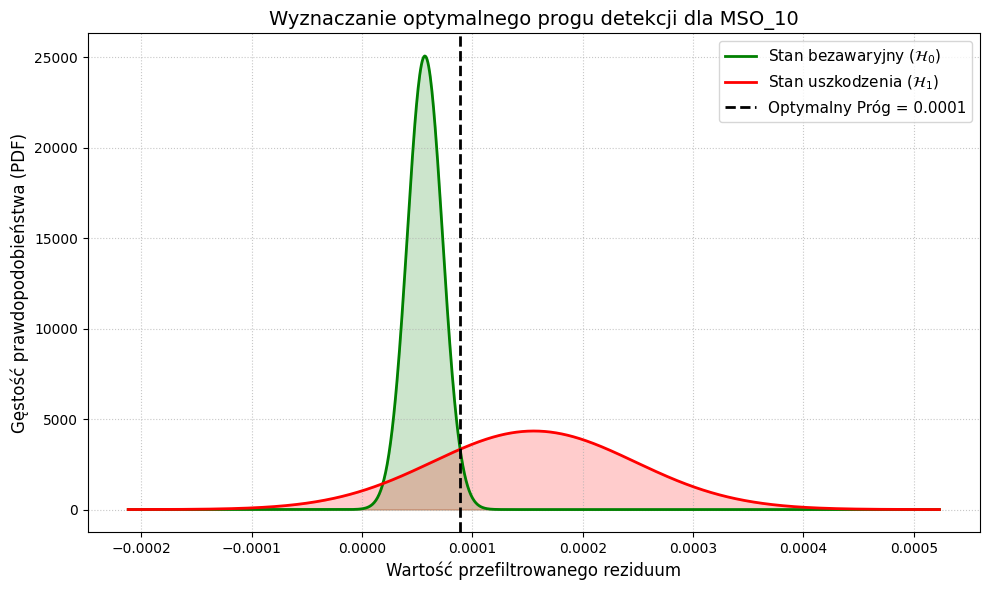

In [6]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import joblib
import matplotlib.pyplot as plt
import scipy.stats as stats
import glob
import os

# ====================================================================
# 1. DEFINICJE SIECI
# ====================================================================
class SubNetwork(nn.Module):
    def __init__(self, input_dim, output_dim=1):
        super(SubNetwork, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256), nn.ReLU(),
            nn.Linear(256, 256), nn.ReLU(),
            nn.Linear(256, output_dim)
        )
    def forward(self, x): 
        return self.net(x)

class GreyBoxSystem_MSO10(nn.Module):
    def __init__(self, T_sample=0.05, num_states=1):
        super(GreyBoxSystem_MSO10, self).__init__()
        # MSO 10 ma 3 wejścia (delta_p, amf, thr) i 1 stan
        self.T, self.num_states, self.num_inputs = T_sample, num_states, 3 
        total_feat = self.num_states + self.num_inputs
        self.g_func = SubNetwork(total_feat, self.num_states) 
        self.h_func = SubNetwork(total_feat, 1)

    def forward(self, u_seq, x_init):
        x_t, preds = x_init, []
        for t in range(u_seq.size(1)):
            inputs = torch.cat((x_t, u_seq[:, t, :]), dim=1)
            preds.append(self.h_func(inputs))
            x_t = x_t + self.T * self.g_func(inputs)
        return torch.stack(preds, dim=1)

# ====================================================================
# 2. FUNKCJE POMOCNICZE
# ====================================================================
def process_multiple_files(file_list, model, scaler_u, scaler_y, burn_in, alpha, start_time_s=0, freq_Hz=20):
    all_residuals = []
    start_idx = int(start_time_s * freq_Hz)
    
    u_cols = ['delta_pressure', 'air_mass_flow', 'throttle_position']
    y_cols = ['injected_fuel_mass']
    
    for file_path in file_list:
        print(f"   Przetwarzanie: {os.path.basename(file_path)} (od {start_time_s} sekundy)...")
        df = pd.read_csv(file_path)
        
        if start_idx > 0:
            df = df.iloc[start_idx:].copy()
        
        # Inżynieria cech dla MSO 10 (delta_pressure)
        df['delta_pressure'] = np.sqrt(np.abs(df['intake_manifold_pressure'] - df['Intercooler_pressure']))
        
        X_tensor = torch.tensor(scaler_u.transform(df[u_cols].values), dtype=torch.float32).unsqueeze(0)
        Y_tensor = torch.tensor(scaler_y.transform(df[y_cols].values), dtype=torch.float32).unsqueeze(0)
        
        x_init = torch.zeros(1, model.num_states)
        y_pred = model(X_tensor, x_init)
        
        y_pred_real = scaler_y.inverse_transform(y_pred[0].cpu().numpy().reshape(-1, 1))
        y_true_real = scaler_y.inverse_transform(Y_tensor[0].cpu().numpy().reshape(-1, 1))
        
        e_raw_abs = np.abs(y_true_real - y_pred_real).flatten()
        e_filtered = np.zeros_like(e_raw_abs)
        e_filtered[0] = e_raw_abs[0]
        
        for i in range(1, len(e_raw_abs)):
            e_filtered[i] = alpha * e_raw_abs[i] + (1 - alpha) * e_filtered[i-1]
            
        all_residuals.extend(e_filtered[burn_in:])
        
    return np.array(all_residuals)

def solve_gaussian_intersection(m1, s1, m2, s2):
    if s1 == s2:
        return (m1 + m2) / 2.0
    
    A = 1/(2*s2**2) - 1/(2*s1**2)
    B = m1/(s1**2) - m2/(s2**2)
    C = m2**2 /(2*s2**2) - m1**2 /(2*s1**2) - np.log(s1/s2)
    
    roots = np.roots([A, B, C])
    for root in roots:
        if min(m1, m2) < root < max(m1, m2):
            return root
            
    return np.mean(roots) 

# ====================================================================
# 3. GŁÓWNY SKRYPT
# ====================================================================
if __name__ == "__main__":
    czestotliwosc_Hz = 20
    burn_in = 100    
    alpha = 0.001 
    DATA_DIR = r"C:\Users\anton\OneDrive\Desktop\data"
    
    HEALTHY_FILES = glob.glob(os.path.join(DATA_DIR, "*_NF*.csv"))
    PIM_FILES = glob.glob(os.path.join(DATA_DIR, "*_pim_*.csv"))
    PIC_FILES = glob.glob(os.path.join(DATA_DIR, "*_pic_*.csv"))
    WAF_FILES = glob.glob(os.path.join(DATA_DIR, "*_waf_*.csv"))
    IML_FILES = glob.glob(os.path.join(DATA_DIR, "*_iml_*.csv")) 

    # ---------------------------------------------------------
    # KOSZYKI FIZYCZNE ZGODNE Z MACIERZĄ FSM DLA MSO_10
    # ---------------------------------------------------------
    # H0: MSO 10 jest ŚLEPE na WAF oraz IML
    FILES_H0 = HEALTHY_FILES + WAF_FILES + IML_FILES
    
    # H1: MSO 10 REAGUJE na usterki czujników ciśnienia PIC i PIM
    FILES_H1 = PIC_FILES + PIM_FILES
    # ---------------------------------------------------------
    
    print("1. Ładowanie modelu i skalerów dla MSO 10...")
    model10 = GreyBoxSystem_MSO10()
    model10.load_state_dict(torch.load(r"C:\Users\anton\OneDrive\Desktop\Diagnosis_System\source\10_rownanie_ciaglosci\szara_skrzynka_mso10_throttle.pth"))
    model10.eval()
    
    scaler_u10 = joblib.load(r"C:\Users\anton\OneDrive\Desktop\Diagnosis_System\source\10_rownanie_ciaglosci\scaler_u_mso10_throttle.pkl")
    scaler_y10 = joblib.load(r"C:\Users\anton\OneDrive\Desktop\Diagnosis_System\source\10_rownanie_ciaglosci\scaler_y_mso10_throttle.pkl")
    
    print(f"\n2. Przetwarzanie danych zdrowych i odprzęgniętych (Ilość plików: {len(FILES_H0)})...")
    with torch.no_grad():
        res_zdrowe = process_multiple_files(FILES_H0, model10, scaler_u10, scaler_y10, burn_in, alpha, start_time_s=0, freq_Hz=czestotliwosc_Hz)
        
    print(f"\n3. Przetwarzanie danych z awariami (Ilość plików: {len(FILES_H1)})...")
    with torch.no_grad():
        res_usterka = process_multiple_files(FILES_H1, model10, scaler_u10, scaler_y10, burn_in, alpha, start_time_s=130, freq_Hz=czestotliwosc_Hz)
        
    # --- STATYSTYKA ---
    mu_0, sigma_0 = np.mean(res_zdrowe), np.std(res_zdrowe)
    mu_1, sigma_1 = np.mean(res_usterka), np.std(res_usterka)
    
    optimal_threshold = solve_gaussian_intersection(mu_0, sigma_0, mu_1, sigma_1)
    
    print(f"\n{'='*50}")
    print(" WYNIKI OPTYMALIZACJI PROGU MSO 10 (Stoustrup & Niemann)")
    print(f"{'='*50}")
    print(f"Dane Zdrowe (H0): mu = {mu_0:.5f}, sigma = {sigma_0:.5f} (na {len(res_zdrowe)} próbkach)")
    print(f"Dane Uszkodz (H1): mu = {mu_1:.5f}, sigma = {sigma_1:.5f} (na {len(res_usterka)} próbkach)")
    print(f"--------------------------------------------------")
    print(f"🚀 OPTYMALNY PRÓG DETEKCJI (Threshold): {optimal_threshold:.5f} [Jednostka modelu]")
    print(f"--------------------------------------------------")

    # ====================================================================
    # 4. TWORZENIE NAUKOWEGO WYKRESU
    # ====================================================================
    plt.figure(figsize=(10, 6))
    
    x = np.linspace(min(mu_0 - 4*sigma_0, mu_1 - 4*sigma_1), 
                    max(mu_0 + 4*sigma_0, mu_1 + 4*sigma_1), 1000)
    
    pdf_zdrowe = stats.norm.pdf(x, mu_0, sigma_0)
    pdf_usterka = stats.norm.pdf(x, mu_1, sigma_1)
    
    plt.plot(x, pdf_zdrowe, color='green', linewidth=2, label=r'Stan bezawaryjny ($\mathcal{H}_0$)')
    plt.fill_between(x, pdf_zdrowe, alpha=0.2, color='green')
    
    plt.plot(x, pdf_usterka, color='red', linewidth=2, label=r'Stan uszkodzenia ($\mathcal{H}_1$)')
    plt.fill_between(x, pdf_usterka, alpha=0.2, color='red')
    
    plt.axvline(optimal_threshold, color='black', linestyle='--', linewidth=2, 
                label=f'Optymalny Próg = {optimal_threshold:.4f}')
    
    plt.title('Wyznaczanie optymalnego progu detekcji dla MSO_10', fontsize=14)
    plt.xlabel('Wartość przefiltrowanego reziduum', fontsize=12)
    plt.ylabel('Gęstość prawdopodobieństwa (PDF)', fontsize=12)
    plt.legend(fontsize=11)
    plt.grid(True, linestyle=':', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

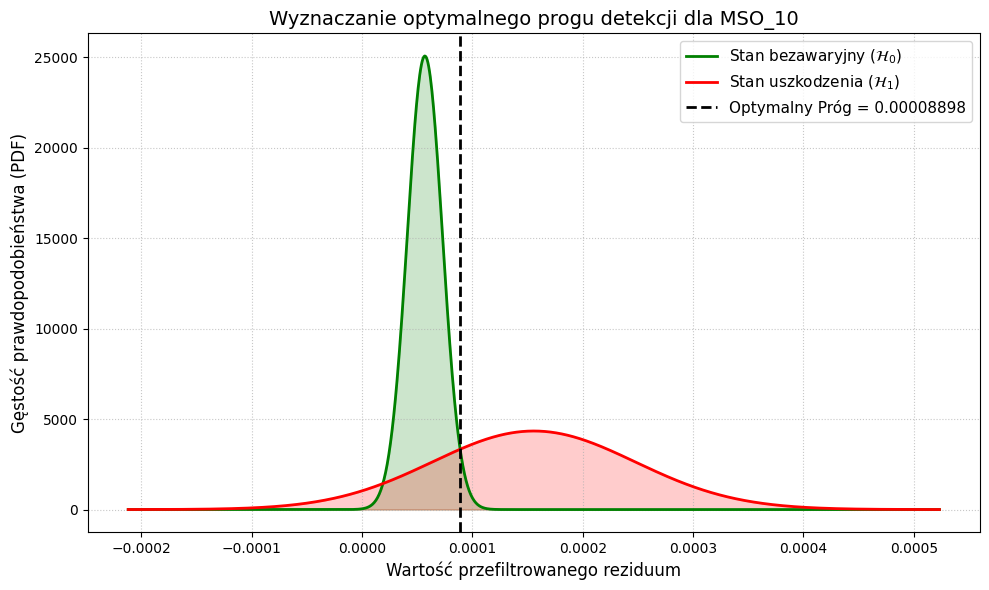

In [7]:
plt.figure(figsize=(10, 6))
    
x = np.linspace(min(mu_0 - 4*sigma_0, mu_1 - 4*sigma_1), 
                    max(mu_0 + 4*sigma_0, mu_1 + 4*sigma_1), 1000)
    
pdf_zdrowe = stats.norm.pdf(x, mu_0, sigma_0)
pdf_usterka = stats.norm.pdf(x, mu_1, sigma_1)
    
plt.plot(x, pdf_zdrowe, color='green', linewidth=2, label=r'Stan bezawaryjny ($\mathcal{H}_0$)')
plt.fill_between(x, pdf_zdrowe, alpha=0.2, color='green')
    
plt.plot(x, pdf_usterka, color='red', linewidth=2, label=r'Stan uszkodzenia ($\mathcal{H}_1$)')
plt.fill_between(x, pdf_usterka, alpha=0.2, color='red')
    
plt.axvline(optimal_threshold, color='black', linestyle='--', linewidth=2, 
                label=f'Optymalny Próg = {optimal_threshold:.8f}')
    
plt.title('Wyznaczanie optymalnego progu detekcji dla MSO_10', fontsize=14)
plt.xlabel('Wartość przefiltrowanego reziduum', fontsize=12)
plt.ylabel('Gęstość prawdopodobieństwa (PDF)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.7)
    
plt.tight_layout()
plt.show()